# Day 3-04｜整合型 Mini Project：Track ID、BEV 路徑與隊伍分群

> 現在我們把前三天的元件串起來：YOLO 找球員、ByteTrack 維持 ID、球場 keypoints 估計 Homography、footpoint 轉成 BEV 座標。  
> 最終每一列資料都回答：**哪一個 track，在哪一個 frame，位於球場上的哪裡？**

## 我們會完成什麼

- 輸出原始視角與 BEV 並排的追蹤影片。
- 讀懂 `track_id -> bbox -> footpoint -> bev_xy` 的資料流。
- 為每個 `track_id` 收集多張 torso crops，以平均 HSV 特徵分成 Team A / B。
- 將隊伍標籤畫回原始 frame，並在 BEV 上用隊伍顏色繪製路徑。
- 將逐 frame 資料與隊伍結果匯出 CSV / JSON。
- 分辨 Homography 暫時失效與 tracking ID 失效是兩種不同問題。


## 前情提要（只保留這次需要的部分）

- Day 1：Homography 負責「相機座標 -> BEV 座標」。
- Day 2：player BBOX 的底邊中心作為 footpoint。
- Day 3-02：ByteTrack 為相鄰 frames 中的同一目標維持 `track_id`。
- Day 3-03：torso crop、HSV histogram 與兩群 K-means 提供隊伍分群基礎。

本 notebook 不再重算手動 IoU 或單張球衣分群；我們專注把 tracking、BEV 與 track-level team clustering 接成完整資料流。


## 工作坊流程

1. 設定影片、player detector、court keypoint model 與 BEV 規格。
2. 執行 tracking-to-BEV pipeline 並觀看左右對照影片。
3. 沿著一列資料檢查 `bbox_xyxy -> foot_x/foot_y -> bev_x/bev_y`。
4. 匯出 CSV，對每個 `track_id` 計算出現範圍與平均位置。
5. 從多個 frames 收集各 Track ID 的 torso crops，建立穩定的隊伍特徵。
6. 畫出帶隊伍框的代表 frame、HSV 特徵分布與 BEV 隊伍路徑。
7. 輸出瀏覽器可播放的分隊追蹤影片。
8. 記錄限制：ID switch、漏偵、球場 keypoint 不足、投影抖動與隊伍誤分。


In [19]:
# 這一格要做什麼：準備課程環境，並以簡短訊息確認載入完成。
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import subprocess
import sys

from IPython.display import Markdown, display

COURSE_ROOT_HINT = next(
    (p for p in [
        Path("/content/drive/MyDrive/basketball_hackathon/course"),  # New: Prioritize Google Drive path
        Path.cwd().resolve(),
        *Path.cwd().resolve().parents
    ] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),  # Fallback if not found anywhere else
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

with redirect_stdout(StringIO()):
    COURSE_ROOT = bootstrap_course_repo(COURSE_ROOT_HINT)
display(Markdown(
    f"✅ **課程環境已就緒**  \n"
    f"專案根目錄：`{COURSE_ROOT}`"
))


✅ **課程環境已就緒**  
專案根目錄：`H:\Repos\basketball-hackathon-course`

## Step 1｜設定整合流程的四種輸入

- 比賽影片：提供每個 frame。
- Player detector：輸出球員 BBOX。
- Court keypoint model：輸出球場固定點，用來估計 Homography。
- BEV 規格：定義鳥瞰球場的大小與線條位置。


In [20]:
# 這一格要做什麼：指定影片、模型與輸出設定，並用一張表確認本次實驗條件。
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from contextlib import redirect_stdout
from io import StringIO
from IPython.display import Markdown, display

from src.video_utils import (
    display_video_in_notebook,
    ensure_notebook_playable_mp4,
)
from src.yolo_utils import (
    detector_model_path,
    preferred_court_keypoint_model_path,
    reference_videos,
    write_bytetrack_bev_video,
)

videos = reference_videos(COURSE_ROOT)
if len(videos) < 3:
    raise FileNotFoundError("assets/raw/reference_videos/ 至少需要三支參考影片。")

VIDEO_PATH = videos[2]
DETECTOR_PATH = detector_model_path(COURSE_ROOT)
COURT_MODEL_PATH = preferred_court_keypoint_model_path(COURSE_ROOT)
BEV_SPEC_PATH = COURSE_ROOT / "assets" / "samples" / "sample_bev_court.json"
OUTPUT_PATH = COURSE_ROOT / "assets" / "results" / "d3_04_bytetrack_bev.mp4"
OUT_CSV = COURSE_ROOT / "assets" / "results" / "d3_04_bytetrack_bev.csv"
START_FRAME = 30
MAX_FRAMES = 45

def readable_number(value: object, digits: int = 1) -> str:
    # 統一數字顯示的小數位數，避免表格出現太長的小數。
    return f"{float(str(value)):.{digits}f}"

def readable_bbox(value: object) -> str:
    # 將 [x1, y1, x2, y2] 改成較容易閱讀的短字串。
    if not isinstance(value, (list, tuple)) or len(value) != 4:
        return str(value)
    return "(" + ", ".join(readable_number(item) for item in value) + ")"

input_overview = pd.DataFrame([
    {"項目": "比賽影片", "本次使用": VIDEO_PATH.name, "用途": "提供逐 frame 影像"},
    {"項目": "Player detector", "本次使用": DETECTOR_PATH.name, "用途": "找出球員 BBOX"},
    {"項目": "Court keypoint model", "本次使用": COURT_MODEL_PATH.name, "用途": "估計 Homography"},
    {"項目": "BEV 規格", "本次使用": BEV_SPEC_PATH.name, "用途": "定義鳥瞰球場座標"},
    {"項目": "處理範圍", "本次使用": f"frame {START_FRAME} 起，共 {MAX_FRAMES} frames", "用途": "控制示範執行時間"},
    {"項目": "輸出影片", "本次使用": OUTPUT_PATH.name, "用途": "保存 tracking-to-BEV 結果"},
])

display(Markdown("### 執行前確認\n下表是這次 pipeline 的輸入與範圍；需要換影片或增加長度時，修改上方大寫變數即可。"))
display(input_overview.set_index("項目"))


### 執行前確認
下表是這次 pipeline 的輸入與範圍；需要換影片或增加長度時，修改上方大寫變數即可。

,本次使用,用途
項目,,
比賽影片,boston-celtics-new-york-knicks-game-1-q1-04.28...,提供逐 frame 影像
Player detector,yolo26n_basketball_player_best.pt,找出球員 BBOX
Court keypoint model,yolo26n_basketball_court_pose_best.pt,估計 Homography
BEV 規格,sample_bev_court.json,定義鳥瞰球場座標
處理範圍,frame 30 起，共 45 frames,控制示範執行時間
輸出影片,d3_04_bytetrack_bev.mp4,保存 tracking-to-BEV 結果


## Step 2｜執行 `detection -> tracking -> footpoint -> Homography`

`write_bytetrack_bev_video()` 內部依序執行：

```text
frame
  -> player BBOX
  -> ByteTrack track_id
  -> BBOX bottom-center footpoint
  -> court keypoints -> Homography
  -> BEV coordinate
```

若當前 frame 的球場 keypoints 不足，程式會短暫沿用上一個可靠 Homography。這能減少 BEV 閃爍，但無法修復長時間看不到球場線的片段。


In [21]:
# 這一格要做什麼：執行 tracking-to-BEV pipeline，先看摘要，再觀看影片。
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="IProgress not found.*")
    with redirect_stdout(StringIO()):
        bev_video, records = write_bytetrack_bev_video(
            video_path=VIDEO_PATH,
            detector_path=DETECTOR_PATH,
            court_model_path=COURT_MODEL_PATH,
            bev_spec_path=BEV_SPEC_PATH,
            output_path=OUTPUT_PATH,
            max_frames=MAX_FRAMES,
            detector_conf=0.25,
            keypoint_conf=0.15,
            anchor_confidence=0.25,
            imgsz=960,
            start_frame=START_FRAME,
        )

record_frame = pd.DataFrame(records)
processed_frame_count = record_frame["frame"].nunique() if not record_frame.empty else 0
tracked_id_count = record_frame["track_id"].nunique() if not record_frame.empty else 0
pipeline_overview = pd.DataFrame([
    {"檢查項目": "處理影格數", "結果": processed_frame_count, "如何解讀": "成功產生資料的不同 frames 數量"},
    {"檢查項目": "逐影格球員紀錄", "結果": len(records), "如何解讀": "一列代表某個 Track ID 在某個 frame 的觀測"},
    {"檢查項目": "不同 Track IDs", "結果": tracked_id_count, "如何解讀": "不等於真實球員人數；ID switch 會增加此數量"},
    {"檢查項目": "預覽影片", "結果": bev_video.name, "如何解讀": "左側相機畫面、右側 BEV 球場"},
])

display(Markdown("### Pipeline 執行摘要\n先確認資料量是否合理，再看影片中的 ID 與 BEV 點是否穩定。"))
display(pipeline_overview.set_index("檢查項目"))
display_video_in_notebook(bev_video, loop=True)


### Pipeline 執行摘要
先確認資料量是否合理，再看影片中的 ID 與 BEV 點是否穩定。

,結果,如何解讀
檢查項目,,
處理影格數,45,成功產生資料的不同 frames 數量
逐影格球員紀錄,426,一列代表某個 Track ID 在某個 frame 的觀測
不同 Track IDs,11,不等於真實球員人數；ID switch 會增加此數量
預覽影片,d3_04_bytetrack_bev.mp4,左側相機畫面、右側 BEV 球場


## Step 3｜沿著一列資料檢查座標如何改變

- `bbox_xyxy`：模型在相機畫面找到的矩形。
- `foot_x, foot_y`：矩形底邊中心，仍是相機像素座標。
- `bev_x, bev_y`：經 Homography 後的鳥瞰球場座標。
- `keypoint_count`：當時有多少球場點可支援 Homography；數量少時要提高警覺。


In [22]:
# 這一格要做什麼：把 records 整理成表格，並用一列範例解釋座標轉換。
track_columns = [
    "frame",
    "track_id",
    "class_name",
    "confidence",
    "bbox_xyxy",
    "foot_x",
    "foot_y",
    "bev_x",
    "bev_y",
    "keypoint_count",
]
tracks = pd.DataFrame(records, columns=track_columns)

if tracks.empty:
    display(Markdown("⚠️ **目前沒有 tracking records。** 請先檢查 detector、影片與 confidence 設定。"))
else:
    first_row = tracks.iloc[0]
    coordinate_story = pd.DataFrame([
        {"資料階段": "1. Tracking 身分", "本列數值": f"frame {first_row['frame']} / Track #{first_row['track_id']}", "代表意義": "哪一位追蹤目標、出現在哪個影格"},
        {"資料階段": "2. Detection BBOX", "本列數值": readable_bbox(first_row["bbox_xyxy"]), "代表意義": "相機畫面中的 (x1, y1, x2, y2) 像素座標"},
        {"資料階段": "3. Footpoint", "本列數值": f"({readable_number(first_row['foot_x'])}, {readable_number(first_row['foot_y'])})", "代表意義": "BBOX 底邊中心，近似球員站在地板的位置"},
        {"資料階段": "4. BEV point", "本列數值": f"({readable_number(first_row['bev_x'])}, {readable_number(first_row['bev_y'])})", "代表意義": "經 Homography 投影後的鳥瞰球場位置"},
    ])
    display(Markdown("### 先讀懂一列資料\n下面四列其實描述的是**同一次球員觀測**，只是座標逐步從相機畫面轉到 BEV。"))
    display(coordinate_story.set_index("資料階段"))

    tracking_preview = (
        tracks[["frame", "track_id", "confidence", "foot_x", "foot_y", "bev_x", "bev_y", "keypoint_count"]]
        .head(10)
        .copy()
        .rename(columns={
            "frame": "影格",
            "track_id": "Track ID",
            "confidence": "偵測信心",
            "foot_x": "落腳點 X (px)",
            "foot_y": "落腳點 Y (px)",
            "bev_x": "BEV X",
            "bev_y": "BEV Y",
            "keypoint_count": "球場關鍵點數",
        })
    )
    numeric_columns = ["偵測信心", "落腳點 X (px)", "落腳點 Y (px)", "BEV X", "BEV Y"]
    tracking_preview[numeric_columns] = tracking_preview[numeric_columns].round(2)
    display(Markdown("### 前 10 筆觀測\n比較同一 Track ID 在不同影格的 BEV 座標，便能開始形成移動路徑。"))
    display(tracking_preview.set_index(["影格", "Track ID"]))


### 先讀懂一列資料
下面四列其實描述的是**同一次球員觀測**，只是座標逐步從相機畫面轉到 BEV。

,本列數值,代表意義
資料階段,,
1. Tracking 身分,frame 30 / Track #5,哪一位追蹤目標、出現在哪個影格
2. Detection BBOX,"(719.4, 298.5, 804.1, 497.2)","相機畫面中的 (x1, y1, x2, y2) 像素座標"
3. Footpoint,"(761.7, 497.2)",BBOX 底邊中心，近似球員站在地板的位置
4. BEV point,"(1630.6, 343.8)",經 Homography 投影後的鳥瞰球場位置


### 前 10 筆觀測
比較同一 Track ID 在不同影格的 BEV 座標，便能開始形成移動路徑。

偵測信心  落腳點 X (px)  落腳點 Y (px)    BEV X    BEV Y  球場關鍵點數
影格 Track ID                                                        
30 5         0.91      761.75      497.17  1630.65   343.78      14
   9         0.96     1235.07      831.58  1735.28   897.08      14
   10        0.86     1170.99      801.13  1717.21   852.54      14
   13        0.88      481.97      782.45  1392.31   738.15      14
   14        0.77      679.26      621.40  1536.35   539.95      14
   1         0.67      577.16      391.95  1564.75   107.98      14
   3         0.88     1065.15      952.98  1612.32  1007.00      14
   7         0.60     1192.32      656.34  1794.66   664.59      14
   18        0.91      665.86      685.49  1508.48   632.79      14
   2         0.88      886.46      660.36  1631.30   627.26      14

## Step 4｜匯出可供研究分析的長表格

這種「每個 frame、每個 track 一列」的長表格可延伸為：

- 單一球員 BEV 路徑與移動距離。
- 速度、加速度與急停事件估計。
- 兩隊陣形、球員間距與攻守站位。
- 與投籃、傳球或回合事件的時間對齊。

注意：`track_id` 不是球員姓名或背號。若要跨片段辨認真實球員，還需要 Re-ID、背號辨識或人工校正。


### Track ID 資料摘要
CSV 已保存為 `d3_04_bytetrack_bev.csv`。觀測影格數越高，代表這個 ID 在片段中維持得越久。

,觀測影格數,首次出現,最後出現,平均 BEV X,平均 BEV Y
Track ID,,,,,
5,45,30,74,1704.2,317.0
9,45,30,74,1695.5,972.3
10,45,30,74,1638.5,850.0
13,45,30,74,1568.4,690.3
7,44,30,74,1761.0,669.2
1,43,30,74,1696.3,98.7
2,43,30,73,1699.7,542.9
3,43,30,74,1467.0,922.9
14,41,30,74,1634.5,497.9


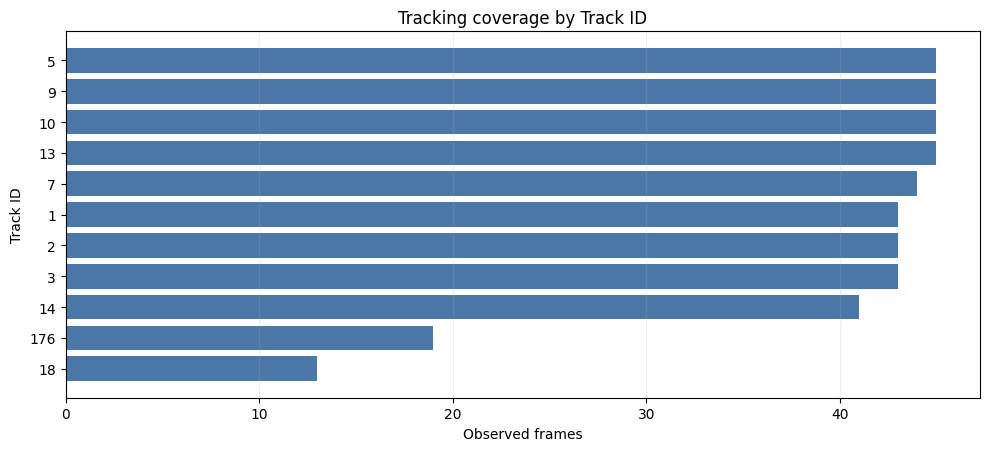

In [23]:
# 這一格要做什麼：匯出 CSV，並用表格與圖形檢查各 Track ID 的資料量。
tracks.to_csv(OUT_CSV, index=False)

if tracks.empty:
    summary = pd.DataFrame(columns=["track_id", "frames_seen", "first_frame", "last_frame", "mean_bev_x", "mean_bev_y"])
else:
    summary = (
        tracks.groupby("track_id", dropna=False)
        .agg(
            frames_seen=("frame", "count"),
            first_frame=("frame", "min"),
            last_frame=("frame", "max"),
            mean_bev_x=("bev_x", "mean"),
            mean_bev_y=("bev_y", "mean"),
        )
        .sort_values(["frames_seen", "first_frame"], ascending=[False, True])
        .reset_index()
    )

summary_view = summary.rename(columns={
    "track_id": "Track ID",
    "frames_seen": "觀測影格數",
    "first_frame": "首次出現",
    "last_frame": "最後出現",
    "mean_bev_x": "平均 BEV X",
    "mean_bev_y": "平均 BEV Y",
}).copy()
if not summary_view.empty:
    summary_view[["平均 BEV X", "平均 BEV Y"]] = summary_view[["平均 BEV X", "平均 BEV Y"]].round(1)

display(Markdown(f"### Track ID 資料摘要\nCSV 已保存為 `{OUT_CSV.name}`。觀測影格數越高，代表這個 ID 在片段中維持得越久。"))
display(summary_view.set_index("Track ID"))

if not summary_view.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.42 * len(summary_view))))
    ax.barh(summary_view["Track ID"].astype(str), summary_view["觀測影格數"], color="#4C78A8")
    ax.invert_yaxis()
    ax.set_title("Tracking coverage by Track ID")
    ax.set_xlabel("Observed frames")
    ax.set_ylabel("Track ID")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()


## Step 5｜加入 Track-level Team Clustering

單張 frame 的球衣可能被遮擋或受到陰影影響，因此這裡不直接沿用單張結果。我們會從多個 frames 收集同一 `track_id` 的 torso crops，先算出每個 track 的平均 HSV histogram，再把 tracks 分成兩群。

```text
tracking records
  -> 按 frame 讀取原始影像
  -> 依 bbox 裁切 torso
  -> 每張 crop 轉成 HSV histogram
  -> 同一 track_id 的 features 取平均
  -> K-means 分成 Team A / B
  -> 將 team label 合併回逐 frame 表格
```

這比單張分群穩定，但仍需記得：若發生 ID switch，兩位球員的 crops 可能被錯誤平均在一起。


### 球衣樣本收集結果
每個 Track ID 會使用多張上半身 crop；樣本越多，單一影格的陰影或遮擋越不容易主導結果。

,採用 crop 數,特徵來源
Track ID,,
1,6,多影格 torso crops 的平均 HSV histogram
2,6,多影格 torso crops 的平均 HSV histogram
3,6,多影格 torso crops 的平均 HSV histogram
5,6,多影格 torso crops 的平均 HSV histogram
7,6,多影格 torso crops 的平均 HSV histogram
9,6,多影格 torso crops 的平均 HSV histogram
10,6,多影格 torso crops 的平均 HSV histogram
13,6,多影格 torso crops 的平均 HSV histogram
14,4,多影格 torso crops 的平均 HSV histogram


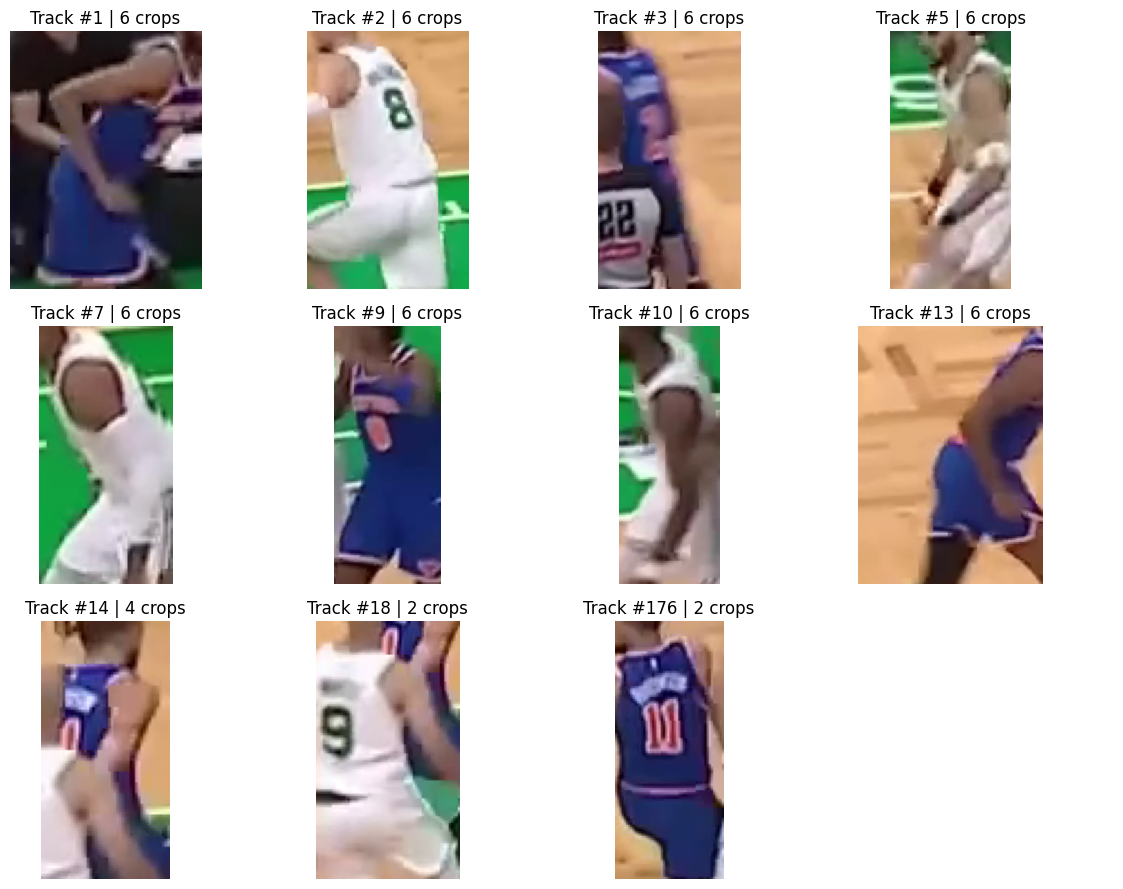

In [24]:
# 這一格要做什麼：從多個 frames 收集每個 Track ID 的 torso crops 與 HSV 特徵。
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

from src.cv_utils import save_json
from src.geometry_utils import render_bev_court

TEAM_SAMPLE_STRIDE = 8   # 每隔幾個 frames 取一次 crop，避免相鄰畫面過度重複。
MAX_CROPS_PER_TRACK = 8  # 每個 track 最多使用幾張球衣 crop。

def scalar_to_int(value: object) -> int:
    # 把 Pandas / NumPy scalar 安全轉成 Python int，並拒絕非整數值。
    numeric_value = float(str(value))
    if not numeric_value.is_integer():
        raise ValueError(f"預期整數，實際收到：{value!r}")
    return int(numeric_value)

def scalar_to_float(value: object) -> float:
    # Pandas 的欄位型別可能被推斷成廣義 Scalar；先轉字串可排除 complex 分支。
    return float(str(value))

def bbox_to_floats(value: object) -> tuple[float, float, float, float]:
    # 明確檢查 BBOX 是四元素序列，讓錯誤資料能提早被發現。
    if not isinstance(value, (list, tuple)) or len(value) != 4:
        raise ValueError(f"BBOX 應包含四個座標，實際收到：{value!r}")
    return (
        scalar_to_float(value[0]),
        scalar_to_float(value[1]),
        scalar_to_float(value[2]),
        scalar_to_float(value[3]),
    )

def torso_crop(image, bbox_xyxy):
    # 只保留 bbox 中央上半身，降低地板、鞋子與背景對顏色的干擾。
    image_h, image_w = image.shape[:2]
    x1, y1, x2, y2 = map(float, bbox_xyxy)
    box_w, box_h = x2 - x1, y2 - y1
    crop_x1 = int(np.clip(x1 + 0.20 * box_w, 0, image_w - 1))
    crop_x2 = int(np.clip(x2 - 0.20 * box_w, crop_x1 + 1, image_w))
    crop_y1 = int(np.clip(y1 + 0.10 * box_h, 0, image_h - 1))
    crop_y2 = int(np.clip(y1 + 0.65 * box_h, crop_y1 + 1, image_h))
    return image[crop_y1:crop_y2, crop_x1:crop_x2]

def color_hist_embedding(crop_rgb, hue_bins=12, saturation_bins=8):
    hsv = cv2.cvtColor(np.ascontiguousarray(crop_rgb), cv2.COLOR_RGB2HSV)
    histogram = cv2.calcHist(
        [hsv], [0, 1], None,
        [hue_bins, saturation_bins], [0, 180, 0, 256],
    ).flatten().astype(np.float32)
    return histogram / max(float(np.linalg.norm(histogram)), 1e-12)

# 只取指定間隔的 frames，並讓每個 track 的 crop 數量有上限。
candidate_rows = tracks[
    ((tracks["frame"] - START_FRAME) % TEAM_SAMPLE_STRIDE == 0)
    & tracks["track_id"].notna()
].copy()
features_by_track = {}
example_crop_by_track = {}
sampled_rows = []
video = cv2.VideoCapture(str(VIDEO_PATH))
if not video.isOpened():
    raise FileNotFoundError(VIDEO_PATH)

for frame_index, frame_rows in candidate_rows.groupby("frame"):
    frame_number = scalar_to_int(frame_index)
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, frame_bgr = video.read()
    if not ok:
        continue
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    for row_index, row in frame_rows.iterrows():
        track_id = scalar_to_int(row["track_id"])
        track_features = features_by_track.setdefault(track_id, [])
        if len(track_features) >= MAX_CROPS_PER_TRACK:
            continue
        crop = torso_crop(frame_rgb, row["bbox_xyxy"])
        if crop.shape[0] < 8 or crop.shape[1] < 8:
            continue
        track_features.append(color_hist_embedding(crop))
        example_crop_by_track.setdefault(track_id, crop)
        sampled_rows.append(row_index)
video.release()

features_by_track = {
    track_id: values for track_id, values in features_by_track.items() if values
}
if len(features_by_track) < 2:
    raise RuntimeError("可用的 Track ID 少於兩個，請降低 TEAM_SAMPLE_STRIDE 或增加 MAX_FRAMES。")

crop_count_table = pd.DataFrame([
    {"Track ID": track_id, "採用 crop 數": len(values), "特徵來源": "多影格 torso crops 的平均 HSV histogram"}
    for track_id, values in sorted(features_by_track.items())
])
display(Markdown(
    "### 球衣樣本收集結果\n"
    "每個 Track ID 會使用多張上半身 crop；樣本越多，單一影格的陰影或遮擋越不容易主導結果。"
))
display(crop_count_table.set_index("Track ID"))

# 直接看 crop，能比一串 histogram 數字更快發現裁判、背景或裁切位置問題。
preview_track_ids = sorted(example_crop_by_track)[:12]
preview_columns = 4
preview_rows = (len(preview_track_ids) + preview_columns - 1) // preview_columns
fig, axes = plt.subplots(preview_rows, preview_columns, figsize=(12, 3 * preview_rows), squeeze=False)
for axis, track_id in zip(axes.flat, preview_track_ids):
    axis.imshow(example_crop_by_track[track_id])
    axis.set_title(f"Track #{track_id} | {len(features_by_track[track_id])} crops")
    axis.axis("off")
for axis in axes.flat[len(preview_track_ids):]:
    axis.axis("off")
plt.tight_layout()
plt.show()


In [25]:
# 這一格要做什麼：先平均同一 Track ID 的多張特徵，再用兩群 K-means 決定隊伍。
def kmeans_two_clusters(feature_matrix, max_iterations=50):
    if len(feature_matrix) < 2:
        raise ValueError("K-means 至少需要兩個 Track IDs。")
    distances_from_first = np.linalg.norm(feature_matrix - feature_matrix[0], axis=1)
    farthest_index = scalar_to_int(np.argmax(distances_from_first).item())
    centers = feature_matrix[[0, farthest_index]].copy()
    labels = np.full(len(feature_matrix), -1, dtype=int)
    iterations_run = 0
    for iteration in range(max_iterations):
        iterations_run = iteration + 1
        distances = np.linalg.norm(
            feature_matrix[:, None, :] - centers[None, :, :], axis=2
        )
        new_labels = distances.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        for cluster_id in (0, 1):
            members = feature_matrix[labels == cluster_id]
            if len(members):
                centers[cluster_id] = members.mean(axis=0)
    return labels, centers, iterations_run

track_ids = sorted(features_by_track)
track_features = np.vstack([
    np.mean(features_by_track[track_id], axis=0) for track_id in track_ids
])
team_labels, team_centers, team_iterations = kmeans_two_clusters(track_features)
team_by_track = {
    track_id: scalar_to_int(team_label.item())
    for track_id, team_label in zip(track_ids, team_labels)
}
team_names = {0: "Team A", 1: "Team B"}
team_colors = {0: "#00B7FF", 1: "#FF4D6D"}

tracks["team_cluster"] = tracks["track_id"].map(team_by_track)
tracks["team_name"] = tracks["team_cluster"].map(team_names).fillna("Unknown")

TEAM_CSV = COURSE_ROOT / "assets" / "results" / "d3_04_bytetrack_bev_teams.csv"
TEAM_JSON = COURSE_ROOT / "assets" / "results" / "d3_04_bytetrack_bev_teams.json"
tracks.to_csv(TEAM_CSV, index=False)
save_json(tracks.to_dict(orient="records"), TEAM_JSON)

team_summary = (
    tracks.dropna(subset=["team_cluster"])
    .groupby(["team_name", "track_id"])
    .agg(frames_seen=("frame", "count"), mean_confidence=("confidence", "mean"))
    .reset_index()
)
team_summary_view = team_summary.rename(columns={
    "team_name": "隊伍",
    "track_id": "Track ID",
    "frames_seen": "觀測影格數",
    "mean_confidence": "平均偵測信心",
}).copy()
team_summary_view["平均偵測信心"] = team_summary_view["平均偵測信心"].round(3)

team_count_view = (
    team_summary_view.groupby("隊伍")["Track ID"]
    .nunique()
    .rename("Track ID 數量")
    .to_frame()
)
output_file_view = pd.DataFrame([
    {"輸出資料": "CSV", "檔名": TEAM_CSV.name, "適合用途": "Pandas、Excel 或統計分析"},
    {"輸出資料": "JSON", "檔名": TEAM_JSON.name, "適合用途": "程式、網頁或 API 串接"},
]).set_index("輸出資料")

display(Markdown(
    f"### 隊伍分群結果\n"
    f"K-means 經過 **{team_iterations} 次更新**後停止。Team A／B 只是群組名稱，不代表真實隊名。"
))
display(team_count_view)
display(Markdown("#### 每個 Track ID 的分隊與資料品質"))
display(team_summary_view.set_index(["隊伍", "Track ID"]))
display(Markdown("#### 已保存的分析檔案"))
display(output_file_view)


### 隊伍分群結果
K-means 經過 **2 次更新**後停止。Team A／B 只是群組名稱，不代表真實隊名。

,Track ID 數量
隊伍,
Team A,5
Team B,6


#### 每個 Track ID 的分隊與資料品質

觀測影格數  平均偵測信心
隊伍     Track ID               
Team A 1            43   0.827
       3            43   0.859
       9            45   0.930
       13           45   0.863
       176          19   0.770
Team B 2            43   0.819
       5            45   0.686
       7            44   0.798
       10           45   0.856
       14           41   0.637
       18           13   0.725

#### 已保存的分析檔案

,檔名,適合用途
輸出資料,,
CSV,d3_04_bytetrack_bev_teams.csv,Pandas、Excel 或統計分析
JSON,d3_04_bytetrack_bev_teams.json,程式、網頁或 API 串接


## Step 6｜輸出隊伍框、特徵分布與 BEV 隊伍路徑

視覺化會同時回答三個問題：

1. 原始 frame 中，每個 Track ID 被分到哪一隊？
2. 各 Track ID 的平均球衣特徵在 2D PCA 視圖中是否自然分開？
3. 兩隊在 BEV 球場上的移動路徑與站位如何分布？


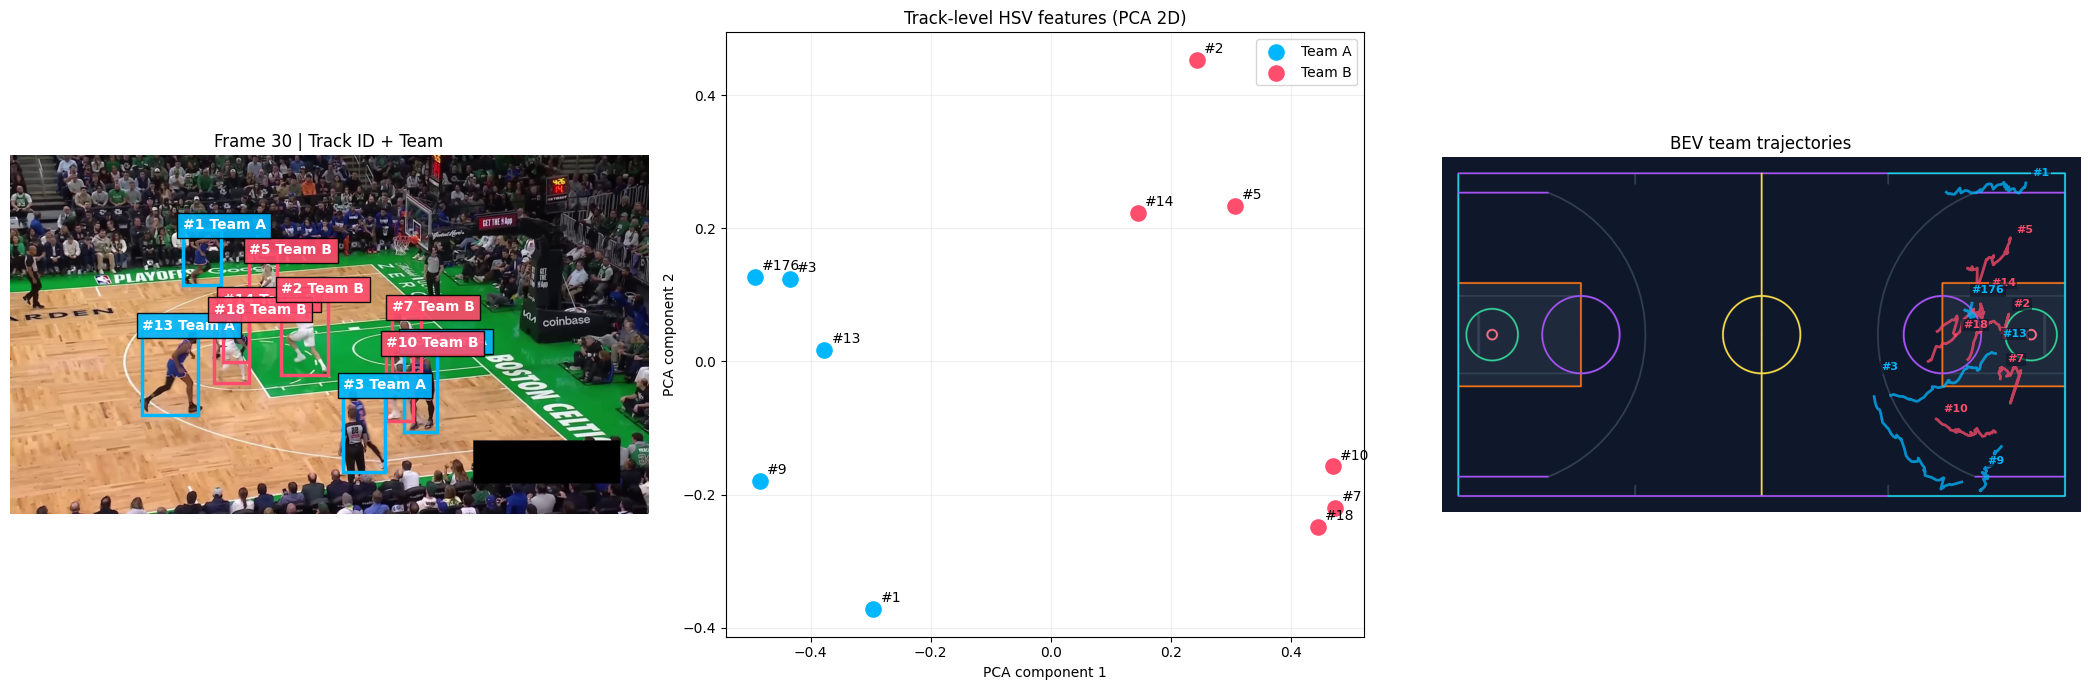

**如何讀這張圖：** 先看左圖的框是否符合球衣顏色，再看中圖兩群是否分開，最後看右圖的隊伍路徑。  
圖片已保存為 `d3_04_team_tracking_visualization.png`。

In [26]:
# 這一格要做什麼：以原始 frame、特徵散點圖與 BEV 路徑三種角度檢查隊伍結果。
sampled_track_rows = tracks.loc[sampled_rows]
visual_frame_index = scalar_to_int(
    sampled_track_rows.groupby("frame").size().idxmax()
)
video = cv2.VideoCapture(str(VIDEO_PATH))
video.set(cv2.CAP_PROP_POS_FRAMES, visual_frame_index)
ok, visual_frame_bgr = video.read()
video.release()
if not ok:
    raise RuntimeError(f"無法讀取代表 frame：{visual_frame_index}")
visual_frame = cv2.cvtColor(visual_frame_bgr, cv2.COLOR_BGR2RGB)

# PCA 只用來畫 2D 散點；實際 K-means 使用完整 HSV features。
centered_features = track_features - track_features.mean(axis=0, keepdims=True)
_, _, vh = np.linalg.svd(centered_features, full_matrices=False)
component_count = min(2, vh.shape[0])
feature_2d = centered_features @ vh[:component_count].T
if component_count == 1:
    feature_2d = np.column_stack([feature_2d[:, 0], np.zeros(len(feature_2d))])

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# 左：代表 frame 的 Track ID 與隊伍框。
axes[0].imshow(visual_frame)
axes[0].set_title(f"Frame {visual_frame_index} | Track ID + Team")
axes[0].axis("off")
for _, row in tracks[tracks["frame"] == visual_frame_index].iterrows():
    row_track_id = scalar_to_int(row["track_id"])
    cluster_id = team_by_track.get(row_track_id)
    if cluster_id is None:
        continue
    x1, y1, x2, y2 = row["bbox_xyxy"]
    color = team_colors[cluster_id]
    axes[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor=color, linewidth=2.5))
    axes[0].text(x1, y1, f"#{row_track_id} {team_names[cluster_id]}",
                 color="white", weight="bold",
                 bbox={"facecolor": color, "alpha": 0.9})

# 中：每個點是一個 Track ID 的平均球衣特徵。
for cluster_id in (0, 1):
    mask = team_labels == cluster_id
    axes[1].scatter(feature_2d[mask, 0], feature_2d[mask, 1], s=120,
                    color=team_colors[cluster_id], label=team_names[cluster_id])
for index, track_id in enumerate(track_ids):
    axes[1].annotate(f"#{track_id}", feature_2d[index], xytext=(5, 5),
                     textcoords="offset points")
axes[1].set_title("Track-level HSV features (PCA 2D)")
axes[1].set_xlabel("PCA component 1")
axes[1].set_ylabel("PCA component 2")
axes[1].legend()
axes[1].grid(alpha=0.2)

# 右：同隊共用顏色，線條分別代表不同 Track IDs 的 BEV 路徑。
bev_image = render_bev_court(BEV_SPEC_PATH)
axes[2].imshow(bev_image)
for path_index, (track_id, path_rows) in enumerate(
    tracks.dropna(subset=["team_cluster"]).groupby("track_id")
):
    cluster_id = scalar_to_int(path_rows["team_cluster"].iloc[0])
    path_track_id = scalar_to_int(track_id)
    ordered = path_rows.sort_values("frame")
    axes[2].plot(ordered["bev_x"], ordered["bev_y"],
                 color=team_colors[cluster_id], linewidth=2, alpha=0.75)
    axes[2].annotate(
        f"#{path_track_id}",
        (ordered["bev_x"].iloc[-1], ordered["bev_y"].iloc[-1]),
        xytext=(5, 5 + (path_index % 3) * 7),
        textcoords="offset points",
        color=team_colors[cluster_id],
        fontsize=8,
        weight="bold",
        bbox={"facecolor": "#101827", "edgecolor": "none", "alpha": 0.65, "pad": 1},
    )
axes[2].set_title("BEV team trajectories")
axes[2].axis("off")

TEAM_VIS_PATH = COURSE_ROOT / "assets" / "results" / "d3_04_team_tracking_visualization.png"
plt.tight_layout()
fig.savefig(TEAM_VIS_PATH, dpi=160, bbox_inches="tight")
plt.show()
display(Markdown(
    f"**如何讀這張圖：** 先看左圖的框是否符合球衣顏色，再看中圖兩群是否分開，最後看右圖的隊伍路徑。  \n"
    f"圖片已保存為 `{TEAM_VIS_PATH.name}`。"
))


## Step 7｜輸出分隊後的追蹤影片

靜態圖適合檢查某一刻的分群，但影片才能看出隊伍標籤是否隨著 Track ID 穩定延續。這一段會產生左右並排的結果：

- **左側原始視角**：每個球員使用所屬隊伍的顏色畫框，並標示 `Track ID + Team`。
- **右側 BEV 視角**：同一個 Track ID 會留下移動軌跡；同隊共用顏色，但仍保留個別 ID。

若標籤突然從一位球員跳到另一位球員，通常表示 tracker 發生 ID switch，而不一定是分群模型突然改變判斷。


In [27]:
# 這一格要做什麼：逐 frame 畫出隊伍框與 BEV 隊伍軌跡，輸出成可播放的 MP4。
from contextlib import redirect_stdout
from io import StringIO

TEAM_VIDEO_PATH = COURSE_ROOT / "assets" / "results" / "d3_04_bytetrack_bev_teams.mp4"
PANEL_WIDTH = 960
PANEL_HEIGHT = 540

def hex_to_bgr(hex_color):
    # Matplotlib 使用 RGB hex；OpenCV 畫圖則需要 BGR tuple。
    value = hex_color.lstrip("#")
    red, green, blue = (int(value[index:index + 2], 16) for index in (0, 2, 4))
    return blue, green, red

team_colors_bgr = {
    cluster_id: hex_to_bgr(color) for cluster_id, color in team_colors.items()
}
rows_by_frame = {
    scalar_to_int(frame_key): frame_rows
    for frame_key, frame_rows in tracks.groupby("frame")
}
trail_history = {track_id: [] for track_id in team_by_track}

source_video = cv2.VideoCapture(str(VIDEO_PATH))
if not source_video.isOpened():
    raise FileNotFoundError(VIDEO_PATH)
source_fps = source_video.get(cv2.CAP_PROP_FPS) or 30.0
source_video.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME)

writer = cv2.VideoWriter(
    str(TEAM_VIDEO_PATH),
    cv2.VideoWriter.fourcc("m", "p", "4", "v"),
    source_fps,
    (PANEL_WIDTH * 2, PANEL_HEIGHT),
)
if not writer.isOpened():
    source_video.release()
    raise RuntimeError(f"無法建立輸出影片：{TEAM_VIDEO_PATH}")

bev_base_rgb = render_bev_court(BEV_SPEC_PATH)
bev_base_bgr = cv2.cvtColor(bev_base_rgb, cv2.COLOR_RGB2BGR)
bev_source_h, bev_source_w = bev_base_bgr.shape[:2]
bev_scale_x = PANEL_WIDTH / bev_source_w
bev_scale_y = PANEL_HEIGHT / bev_source_h

written_frames = 0
for frame_number in range(START_FRAME, START_FRAME + MAX_FRAMES):
    ok, frame_bgr = source_video.read()
    if not ok:
        break

    source_h, source_w = frame_bgr.shape[:2]
    camera_panel = cv2.resize(frame_bgr, (PANEL_WIDTH, PANEL_HEIGHT))
    camera_scale_x = PANEL_WIDTH / source_w
    camera_scale_y = PANEL_HEIGHT / source_h
    bev_panel = cv2.resize(bev_base_bgr, (PANEL_WIDTH, PANEL_HEIGHT))
    frame_rows = rows_by_frame.get(frame_number)

    if frame_rows is not None:
        for row in frame_rows.itertuples(index=False):
            track_id = scalar_to_int(row.track_id)
            cluster_id = team_by_track.get(track_id)
            if cluster_id is None:
                continue
            color = team_colors_bgr[cluster_id]
            x1, y1, x2, y2 = bbox_to_floats(row.bbox_xyxy)
            box_start = (round(x1 * camera_scale_x), round(y1 * camera_scale_y))
            box_end = (round(x2 * camera_scale_x), round(y2 * camera_scale_y))
            cv2.rectangle(camera_panel, box_start, box_end, color, 3)

            label = f"#{track_id} {team_names[cluster_id]}"
            (label_w, label_h), _ = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
            )
            label_top = max(0, box_start[1] - label_h - 10)
            cv2.rectangle(
                camera_panel,
                (box_start[0], label_top),
                (box_start[0] + label_w + 10, label_top + label_h + 10),
                color,
                -1,
            )
            cv2.putText(
                camera_panel, label, (box_start[0] + 5, label_top + label_h + 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA,
            )

            bev_point = (
                round(scalar_to_float(row.bev_x) * bev_scale_x),
                round(scalar_to_float(row.bev_y) * bev_scale_y),
            )
            trail_history[track_id].append(bev_point)

    # 每一幀都重畫目前累積的軌跡，讓學生看見每位球員如何移動。
    for track_id, points in trail_history.items():
        if not points:
            continue
        cluster_id = team_by_track[track_id]
        color = team_colors_bgr[cluster_id]
        if len(points) >= 2:
            cv2.polylines(
                bev_panel, [np.asarray(points, dtype=np.int32)], False,
                color, 3, cv2.LINE_AA,
            )
        cv2.circle(bev_panel, points[-1], 7, color, -1, cv2.LINE_AA)
        cv2.putText(
            bev_panel, f"#{track_id}", (points[-1][0] + 8, points[-1][1] - 8),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA,
        )

    cv2.putText(camera_panel, "Camera view | Track ID + Team", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(bev_panel, "BEV | Team-colored trajectories", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255, 255, 255), 2, cv2.LINE_AA)
    writer.write(np.hstack([camera_panel, bev_panel]))
    written_frames += 1

source_video.release()
writer.release()
if written_frames == 0:
    raise RuntimeError("沒有成功寫入任何分隊影片 frame。")

# OpenCV 的 mp4v 並非所有瀏覽器都能播放；轉成 H.264 + yuv420p 後再嵌入 notebook。
with redirect_stdout(StringIO()):
    ensure_notebook_playable_mp4(TEAM_VIDEO_PATH)
video_summary = pd.DataFrame([
    {"影片資訊": "畫面配置", "結果": "左：相機隊伍框｜右：BEV 隊伍軌跡"},
    {"影片資訊": "解析度", "結果": f"{PANEL_WIDTH * 2} x {PANEL_HEIGHT}"},
    {"影片資訊": "影格數", "結果": written_frames},
    {"影片資訊": "長度", "結果": f"{written_frames / source_fps:.2f} 秒"},
    {"影片資訊": "瀏覽器編碼", "結果": "H.264 / yuv420p"},
    {"影片資訊": "輸出檔名", "結果": TEAM_VIDEO_PATH.name},
]).set_index("影片資訊")

display(Markdown(
    "### 分隊影片輸出完成\n"
    "🟦 **Team A**　🟥 **Team B**。播放時請觀察同一 Track ID 的顏色是否持續一致。"
))
display(video_summary)
display_video_in_notebook(TEAM_VIDEO_PATH, loop=True)


### 分隊影片輸出完成
🟦 **Team A**　🟥 **Team B**。播放時請觀察同一 Track ID 的顏色是否持續一致。

,結果
影片資訊,
畫面配置,左：相機隊伍框｜右：BEV 隊伍軌跡
解析度,1920 x 540
影格數,45
長度,1.50 秒
瀏覽器編碼,H.264 / yuv420p
輸出檔名,d3_04_bytetrack_bev_teams.mp4


## Mini Project 完成檢查與限制

### 本單元產出

- `assets/results/d3_04_bytetrack_bev.mp4`：原始視角與 BEV 並排追蹤影片。
- `assets/results/d3_04_bytetrack_bev.json`：原始 tracking-to-BEV records。
- `assets/results/d3_04_bytetrack_bev.csv`：未加入隊伍前的逐 frame 長表格。
- `assets/results/d3_04_bytetrack_bev_teams.csv` / `.json`：加入 Team A / B 的資料。
- `assets/results/d3_04_team_tracking_visualization.png`：原圖隊伍框、特徵散點與 BEV 隊伍路徑。
- `assets/results/d3_04_bytetrack_bev_teams.mp4`：分隊後的原始視角與 BEV 軌跡並排影片。

### 解讀限制

- Homography 錯誤會讓 BEV 位置偏移，但不一定改變 Track ID 或隊伍。
- ID switch 會讓兩位球員的球衣 features 與路徑混在一起。
- Team A / B 是無標籤群編號，不是真實隊名；重跑或換資料後編號可能交換。
- 裁判、相似球衣、陰影與嚴重遮擋仍可能造成誤分。正式專案應加入裁判排除、人工校正或影像 embedding。
